In [1]:
print('hello world')

hello world


# Indian Sign Language (ISL) Recognition
**Business Case:** Develop a Machine Learning model for Indian Sign Language recognition to improve communication accessibility for the deaf and hard-of-hearing community in India

**Approach:** Transfer Learning using MobileNetV2 for multi-class image classification

In [2]:
### imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [3]:
import os
base = r'D:\AI COURSE\Daily_practice\PROJECTS'
for folder in os.listdir(base):
    print(folder)

Busniess Cases for Client Projects.docx
Chest-Xray-2
churn-prediction
Indi_sign_language.ipynb
Pneumonia_chest_xray.ipynb
PRAICP-1000-IndiSignLang
PRAICP-1000-IndiSignLang.docx
PRAICP-1000-IndiSignLang.zip
PRAICP-1002-TrafSignDetc.docx
PRAICP-1004-Rainfall-TS.docx
PRAICP-1004-RainfallTS
PRAICP-1012-Pneumonia_chest_x-ray_classification.docx
Rainfall_pred.ipynb
Traffic_sign_detc.ipynb


In [11]:
### path & configuration

path = r'D:\AI COURSE\Daily_practice\PROJECTS\PRAICP-1000-IndiSignLang\Data'

IMG_SIZE   = (224, 224)   # MobileNetV2 expected input
BATCH_SIZE = 32
EPOCHS_FROZEN  = 10      # Train only top layers first
EPOCHS_FINETUNE = 10     # Fine-tune last few base layers
SEED = 42

CLASS_NAMES = sorted(os.listdir(path))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


## Data exploring

In [12]:
### couting images per class

class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(path, cls)
    class_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

total_images = sum(class_counts.values())
print(f'Total images: {total_images}')
print(pd.Series(class_counts, name='count').to_string())

Total images: 4972
A    242
B    259
C    247
D    147
E    243
F    226
G    241
H    116
I    179
K    245
L    182
M    235
N    237
O    229
P    234
Q    216
R    211
S    229
T    216
U    135
V    122
W    128
X    202
Y    251


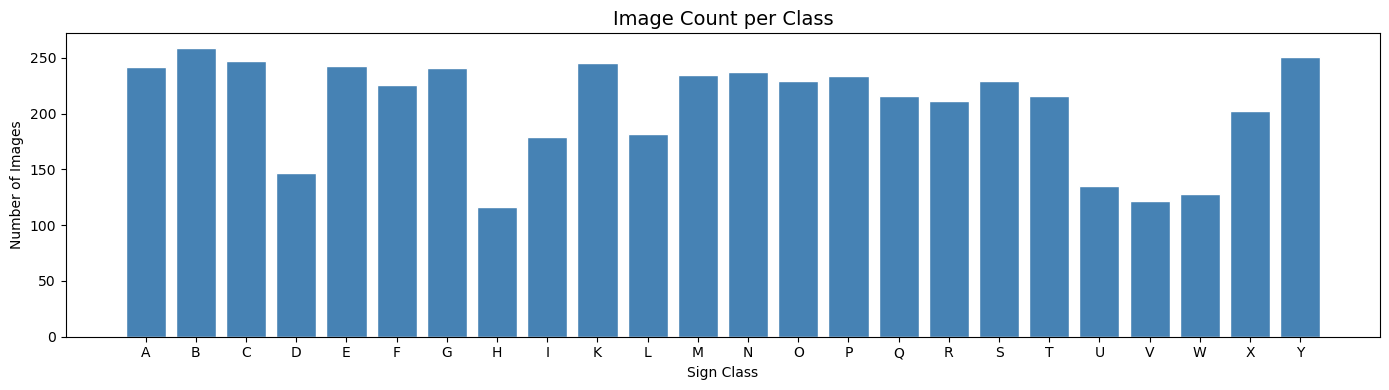

In [13]:
### class distribution bar chart

plt.figure(figsize=(14, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
plt.title('Image Count per Class', fontsize=14)
plt.xlabel('Sign Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

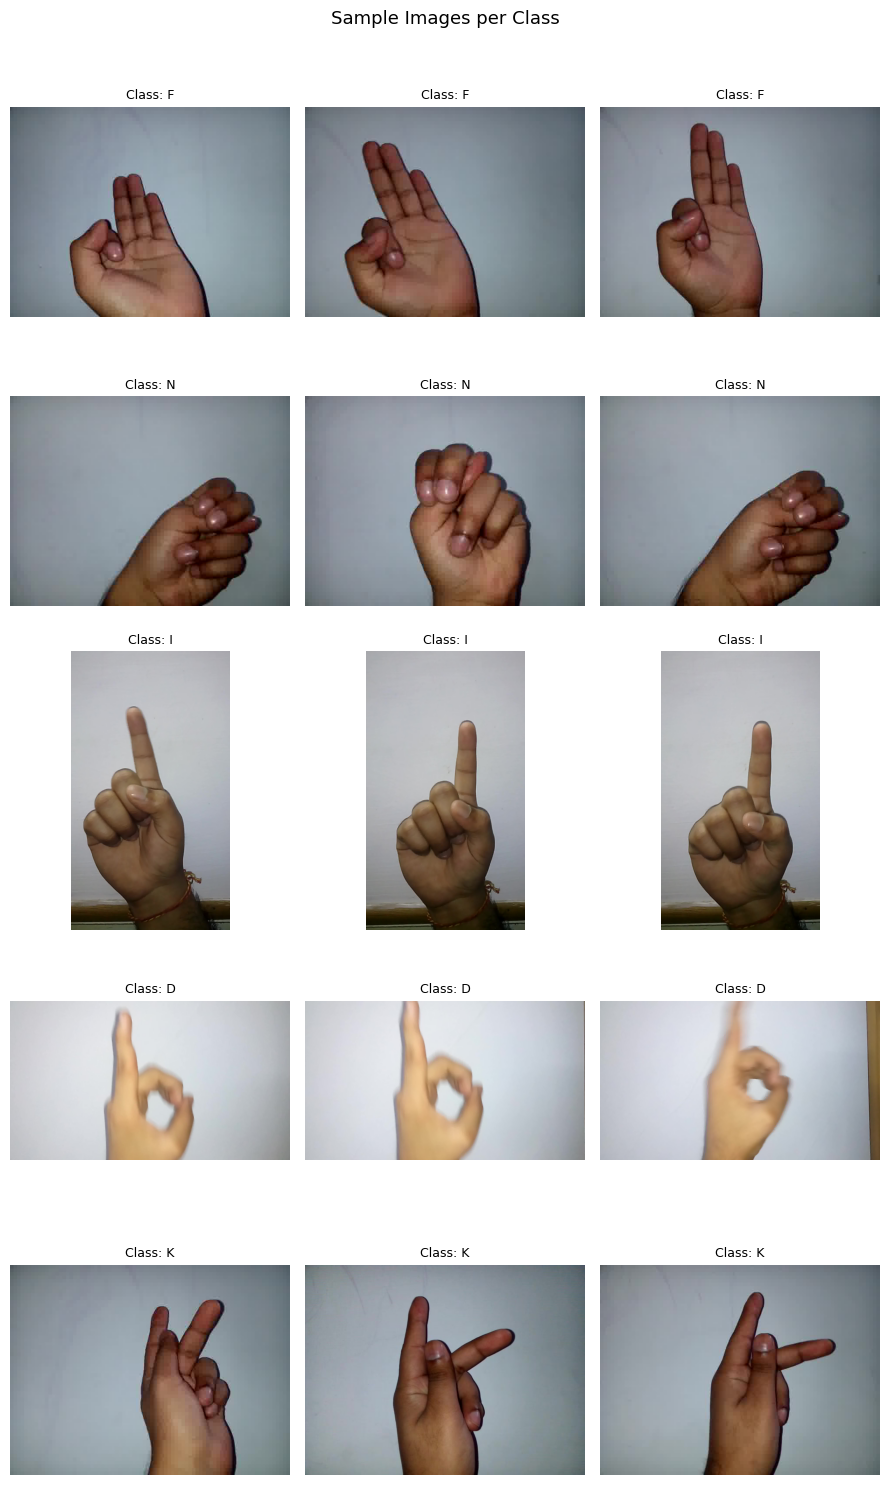

In [14]:
# visualise sample images — 5 classes x 3 images
import random
from PIL import Image

sample_classes = random.sample(CLASS_NAMES, 5)
fig, axes = plt.subplots(5, 3, figsize=(9, 15))

for row, cls in enumerate(sample_classes):
    cls_path = os.path.join(path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(3, len(images)))
    for col, img_file in enumerate(samples):
        img = Image.open(os.path.join(cls_path, img_file))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'Class: {cls}', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Sample Images per Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Data preprocessing & augmentation

In [15]:
# train augmentation - to prevent overfitting

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,   # sign language is direction-sensitive
    fill_mode='nearest'
)

# Validation — only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f'Training samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Class indices     : {train_generator.class_indices}')

Found 3987 images belonging to 24 classes.
Found 985 images belonging to 24 classes.
Training samples  : 3987
Validation samples: 985
Class indices     : {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'O': 13, 'P': 14, 'Q': 15, 'R': 16, 'S': 17, 'T': 18, 'U': 19, 'V': 20, 'W': 21, 'X': 22, 'Y': 23}


## Model Building — Transfer Learning with MobileNetV2

In [16]:

base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model — only train custom head first
base_model.trainable = False

# Build custom classification head
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,912 (10.00 MB)

 Trainable params: 363,928 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 1: Train Classification Head 

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=val_generator,
    callbacks=callbacks_phase1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.6022 - loss: 1.3864 - val_accuracy: 0.9279 - val_loss: 0.2845 - learning_rate: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9102 - loss: 0.3056 - val_accuracy: 0.9513 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9516 - loss: 0.1631 - val_accuracy: 0.9503 - val_loss: 0.1291 - learning_rate: 0.0010
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.9684 - loss: 0.1100 - val_accuracy: 0.9604 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9744 - loss: 0.0817 - val_accuracy: 0.9675 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9779 - loss: 0.0694 - val_accuracy: 0.9685 - val_loss: 0.1072 - learning_rate: 0.0010
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9821 - loss: 0.06

## Phase 2: Fine-Tuning 

In [19]:
# Unfreeze the last 30 layers of the base model for fine-tuning

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_isl_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_generator,
    callbacks=callbacks_phase2
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8786 - loss: 0.4884
Epoch 1: val_accuracy improved from None to 0.96244, saving model to best_isl_model.keras

Epoch 1: finished saving model to best_isl_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9496 - loss: 0.1890 - val_accuracy: 0.9624 - val_loss: 0.1593 - learning_rate: 1.0000e-04
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9924 - loss: 0.0265
Epoch 2: val_accuracy improved from 0.96244 to 0.97157, saving model to best_isl_model.keras

Epoch 2: finished saving model to best_isl_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9930 - loss: 0.0254 - val_accuracy: 0.9716 - val_loss: 0.1667 - learning_rate: 1.0000e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9956 - loss: 0.0135
Epoch 3: val_accuracy did not improve from 0.97157

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 1

## training curves

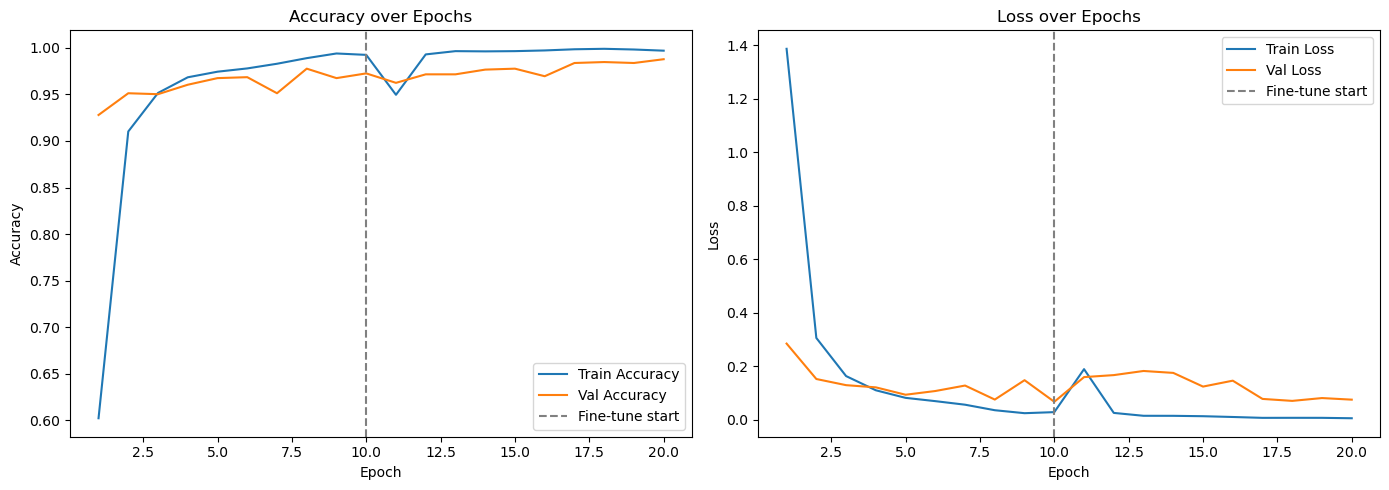

In [ ]:
def plot_history(h1, h2):
    acc  = h1.history['accuracy']      + h2.history['accuracy']
    val  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss = h1.history['loss']          + h2.history['loss']
    vloss= h1.history['val_loss']      + h2.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    phase_boundary = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc,  label='Train Accuracy')
    ax1.plot(epochs_range, val,  label='Val Accuracy')
    ax1.axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(epochs_range, loss,  label='Train Loss')
    ax2.plot(epochs_range, vloss, label='Val Loss')
    ax2.axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

### observations here

- Model converges by epoch 5 in Phase 1. Fine-tuning Phase 2 pushed val accuracy from 96.8% to 98.78%, confirming that unfreezing the last 30 layers of MobileNetV2 extracted more task-specific features.

## Evaluation

In [21]:

best_model = keras.models.load_model('best_isl_model.keras')

val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
print(f'\nValidation Accuracy : {val_acc:.4f}')
print(f'Validation Loss     : {val_loss:.4f}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 583ms/step - accuracy: 0.9878 - loss: 0.0750

Validation Accuracy : 0.9878
Validation Loss     : 0.0750


In [22]:
# Predictions for classification report & confusion matrix

val_generator.reset()
y_pred_probs = best_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

labels = list(val_generator.class_indices.keys())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=labels))

31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 691ms/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        48
           B       1.00      1.00      1.00        51
           C       1.00      1.00      1.00        49
           D       1.00      1.00      1.00        29
           E       1.00      1.00      1.00        48
           F       1.00      1.00      1.00        45
           G       1.00      1.00      1.00        48
           H       1.00      1.00      1.00        23
           I       1.00      1.00      1.00        35
           K       1.00      1.00      1.00        49
           L       1.00      1.00      1.00        36
           M       1.00      1.00      1.00        47
           N       0.96      1.00      0.98        47
           O       1.00      1.00      1.00        45
           P       1.00      1.00      1.00        46
           Q       1.00      1.00      1.00        43
           R   

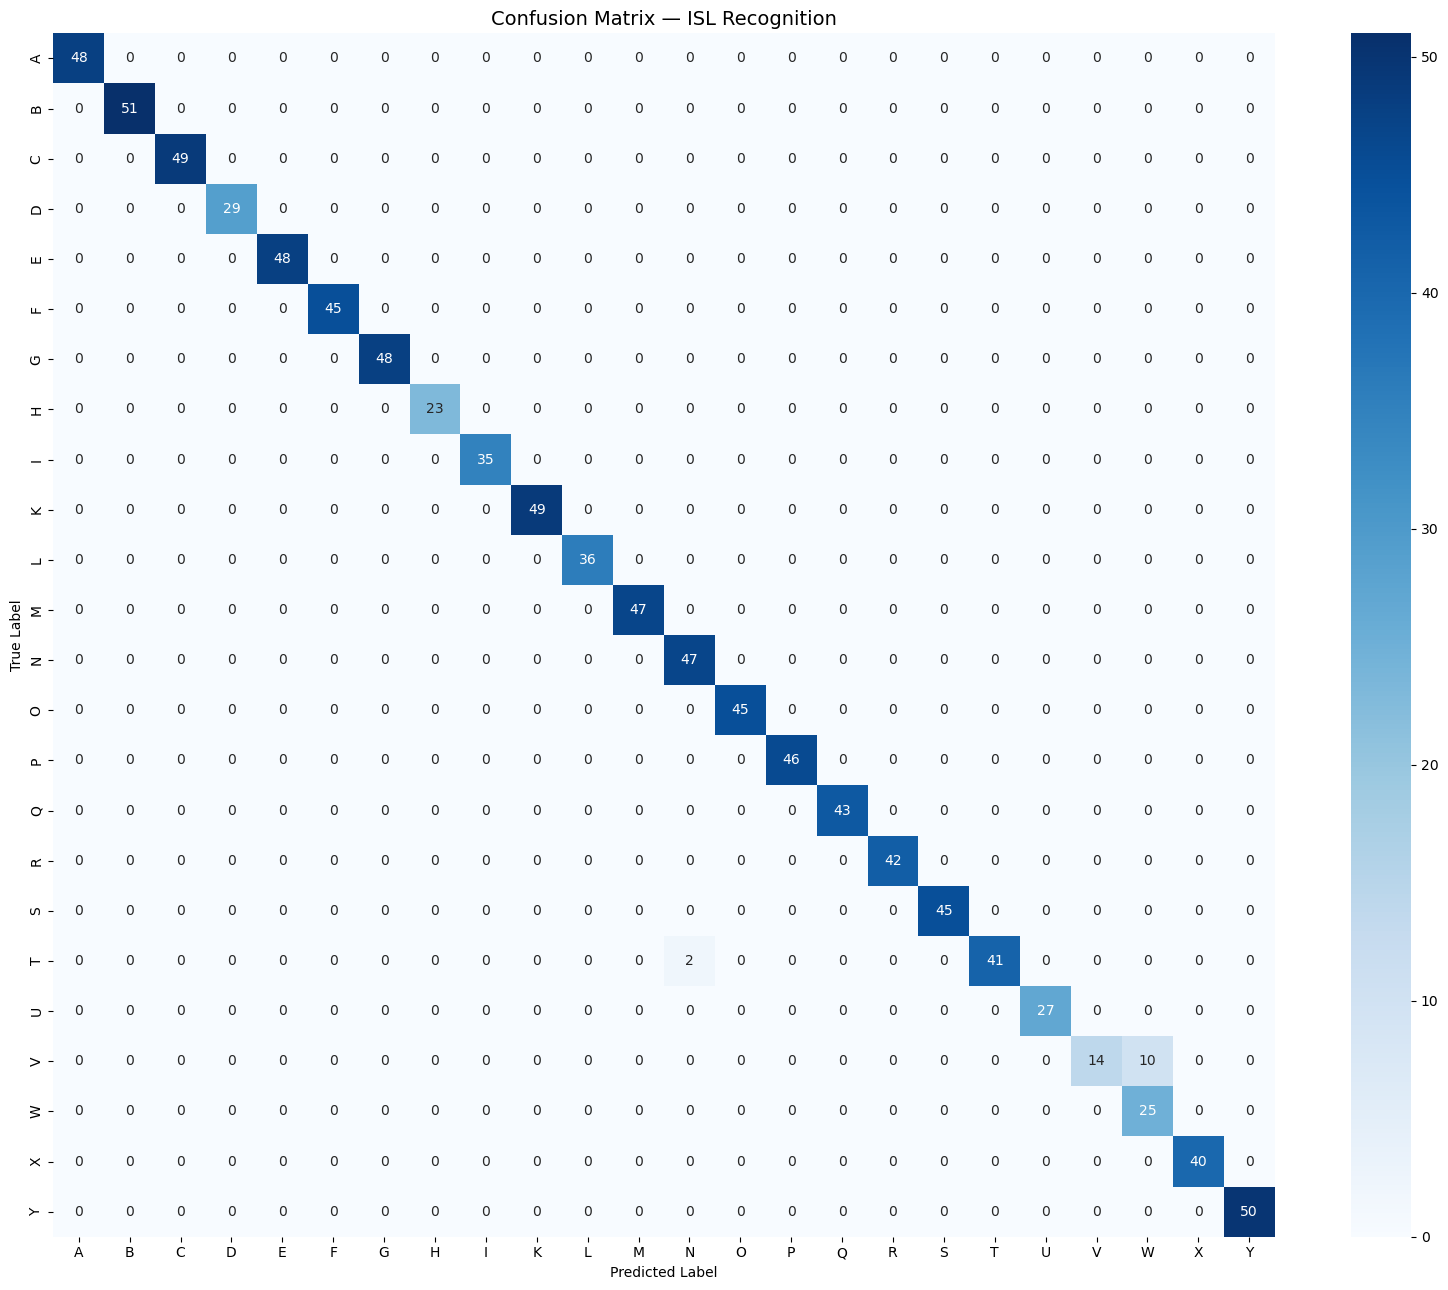

In [23]:
# confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — ISL Recognition', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### observations here

- The model achieves near-perfect classification across all 24 classes.
- The only notable confusion is between V and W (10 cases), which is expected given their visual similarity in static ISL hand gestures. 
- T and M share 2 misclassifications for the same reason.